In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Charger le fichier Excel
departments = pd.read_csv("C:/Users/HUGO/Downloads/archive/departments.csv")
aisles = pd.read_csv("C:/Users/HUGO/Downloads/archive/aisles.csv")
products = pd.read_csv("C:/Users/HUGO/Downloads/archive/products.csv")
orders = pd.read_csv("C:/Users/HUGO/Downloads/archive/orders.csv")
order_products_previous = pd.read_csv("C:/Users/HUGO/Downloads/archive/order_products__prior.csv")
order_products_train  = pd.read_csv("C:/Users/HUGO/Downloads/archive/order_products__train.csv")


In [6]:
print("departments shape:", departments.shape)
print("aisles shape:", aisles.shape)
print("products shape:", products.shape)
print("orders shape:", orders.shape)
print("order_products__prior shape:", order_products_previous.shape)
print("order_products__train shape:", order_products_train .shape)

departments shape: (21, 2)
aisles shape: (134, 2)
products shape: (49688, 4)
orders shape: (3421083, 7)
order_products__prior shape: (32434489, 4)
order_products__train shape: (1384617, 4)


In [7]:
def data_audit(df, name):
    print("\n" + "="*70)
    print(f"DATASET: {name}")
    print("="*70)
    
    # Shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # Memory usage
    memory = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage: {memory:.2f} MB")
    
    # Duplicate rows
    duplicates = df.duplicated().sum()
    print(f"Duplicate rows: {duplicates}")
    
    # Missing values
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        "Missing Values": missing,
        "Missing %": missing_percent
    }).sort_values(by="Missing %", ascending=False)
    
    print("\nMissing Values (only columns with missing data):")
    print(missing_df[missing_df["Missing Values"] > 0])
    
    # Data types
    print("\nData Types:")
    print(df.dtypes)
    
    # Numeric summary
    print("\nNumeric Summary:")
    print(df.describe())
    
    # Categorical quick summary
    print("\nCategorical Columns Top Values:")
    cat_cols = df.select_dtypes(include='object').columns
    
    for col in cat_cols:
        print(f"\nTop 5 values in '{col}':")
        print(df[col].value_counts().head())
    
    print("\n" + "="*70)
    print("END OF AUDIT")
    print("="*70 + "\n")


# ==============================
# APPLIQUER SUR TOUS LES DATASETS
# ==============================

datasets = {
    "departments": departments,
    "aisles": aisles,
    "products": products,
    "orders": orders,
    "order_products__prior": order_products_previous,
    "order_products__train": order_products_train
}

for name, df in datasets.items():
    data_audit(df, name)


DATASET: departments
Shape: 21 rows, 2 columns
Memory usage: 0.00 MB
Duplicate rows: 0

Missing Values (only columns with missing data):
Empty DataFrame
Columns: [Missing Values, Missing %]
Index: []

Data Types:
department_id     int64
department       object
dtype: object

Numeric Summary:
       department_id
count      21.000000
mean       11.000000
std         6.204837
min         1.000000
25%         6.000000
50%        11.000000
75%        16.000000
max        21.000000

Categorical Columns Top Values:

Top 5 values in 'department':
department
frozen          1
meat seafood    1
deli            1
snacks          1
babies          1
Name: count, dtype: int64

END OF AUDIT


DATASET: aisles
Shape: 134 rows, 2 columns
Memory usage: 0.01 MB
Duplicate rows: 0

Missing Values (only columns with missing data):
Empty DataFrame
Columns: [Missing Values, Missing %]
Index: []

Data Types:
aisle_id     int64
aisle       object
dtype: object

Numeric Summary:
         aisle_id
count  134.00

In [8]:
datasets = [orders, order_products_previous , order_products_train , aisles , products , departments]

dataset_name = ['orders','order_products__prior' , 'order_products__train' , 'aisles' , 'products' , 'departments' ]

In [9]:
print('Checking for Null values in the dataset :\n')
for i in range(len(datasets)):
    print('Data set name :',dataset_name[i])
    print('Data set shape :')
    print(datasets[i].isnull().sum())
    print('*' * 30)
    print('*' * 30)

Checking for Null values in the dataset :

Data set name : orders
Data set shape :
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64
******************************
******************************
Data set name : order_products__prior
Data set shape :
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
******************************
******************************
Data set name : order_products__train
Data set shape :
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
******************************
******************************
Data set name : aisles
Data set shape :
aisle_id    0
aisle       0
dtype: int64
******************************
******************************
Data set name : products

In [10]:
print('Describing values in the dataset :\n')
for i in range(len(datasets)):
    print('Data set name :',dataset_name[i])
    print('Data set shape :')
    print(datasets[i].describe())
    print('*' * 30)
    print('*' * 30)

Describing values in the dataset :

Data set name : orders
Data set shape :
           order_id       user_id  order_number     order_dow  \
count  3.421083e+06  3.421083e+06  3.421083e+06  3.421083e+06   
mean   1.710542e+06  1.029782e+05  1.715486e+01  2.776219e+00   
std    9.875817e+05  5.953372e+04  1.773316e+01  2.046829e+00   
min    1.000000e+00  1.000000e+00  1.000000e+00  0.000000e+00   
25%    8.552715e+05  5.139400e+04  5.000000e+00  1.000000e+00   
50%    1.710542e+06  1.026890e+05  1.100000e+01  3.000000e+00   
75%    2.565812e+06  1.543850e+05  2.300000e+01  5.000000e+00   
max    3.421083e+06  2.062090e+05  1.000000e+02  6.000000e+00   

       order_hour_of_day  days_since_prior_order  
count       3.421083e+06            3.214874e+06  
mean        1.345202e+01            1.111484e+01  
std         4.226088e+00            9.206737e+00  
min         0.000000e+00            0.000000e+00  
25%         1.000000e+01            4.000000e+00  
50%         1.300000e+01        

In [11]:
orders.eval_set.value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

In [12]:
import numpy as np
def get_unique_count(x):
    return len(np.unique(x))

orders.groupby("eval_set")["user_id"].aggregate(get_unique_count)

eval_set
prior    206209
test      75000
train    131209
Name: user_id, dtype: int64

In [13]:
orders['user_id'].nunique()

206209

In [14]:
op_all_df = pd.concat([order_products_train, order_products_previous], axis=0)
print("The order_products_all size is : ", op_all_df.shape)

The order_products_all size is :  (33819106, 4)


In [15]:
# Check the number of unique orders and unique products
orders_Unique = len(set(op_all_df.order_id))
products_Unique = len(set(op_all_df.product_id))
print("There are %s orders for %s products" %(orders_Unique, products_Unique))

There are 3346083 orders for 49685 products


# **Number of products that people usually order**

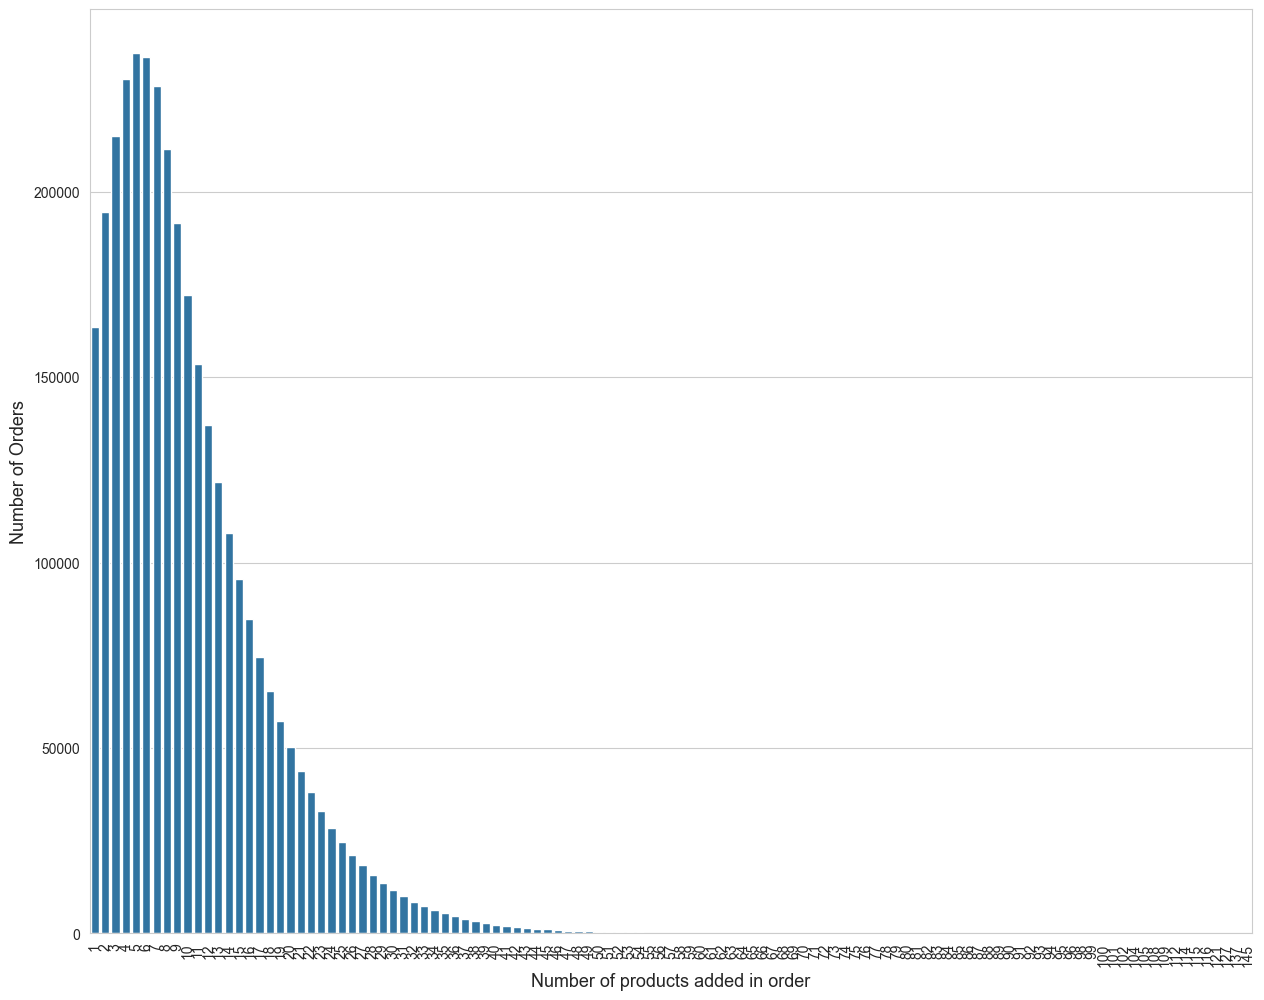

In [16]:
grouped = op_all_df.groupby("order_id")["add_to_cart_order"].max().reset_index()
grouped = grouped["add_to_cart_order"].value_counts().sort_index()



sns.set_style('whitegrid')
plt.figure(figsize=(15, 12))

sns.barplot(
    x=grouped.index,
    y=grouped.values
)

plt.xticks(rotation=90)
plt.ylabel('Number of Orders', fontsize=13)
plt.xlabel('Number of products added in order', fontsize=13)
plt.show()

# **Most ordered products**

In [17]:
grouped = (
    op_all_df
    .groupby("product_id")
    .agg(Total_orders=("reordered", "count"))
    .reset_index()
)
grouped = grouped.merge(
    products[['product_id', 'product_name']],
    on="product_id",
    how="left"
)

grouped = grouped.sort_values(by='Total_orders', ascending=False).head(10)

grouped

,product_id,Total_orders,product_name
24849,24852,491291,Banana
13173,13176,394930,Bag of Organic Bananas
21134,21137,275577,Organic Strawberries
21900,21903,251705,Organic Baby Spinach
47205,47209,220877,Organic Hass Avocado
47762,47766,184224,Organic Avocado
47622,47626,160792,Large Lemon
16794,16797,149445,Strawberries
26206,26209,146660,Limes
27842,27845,142813,Organic Whole Milk


# **Time at which people usually order products**

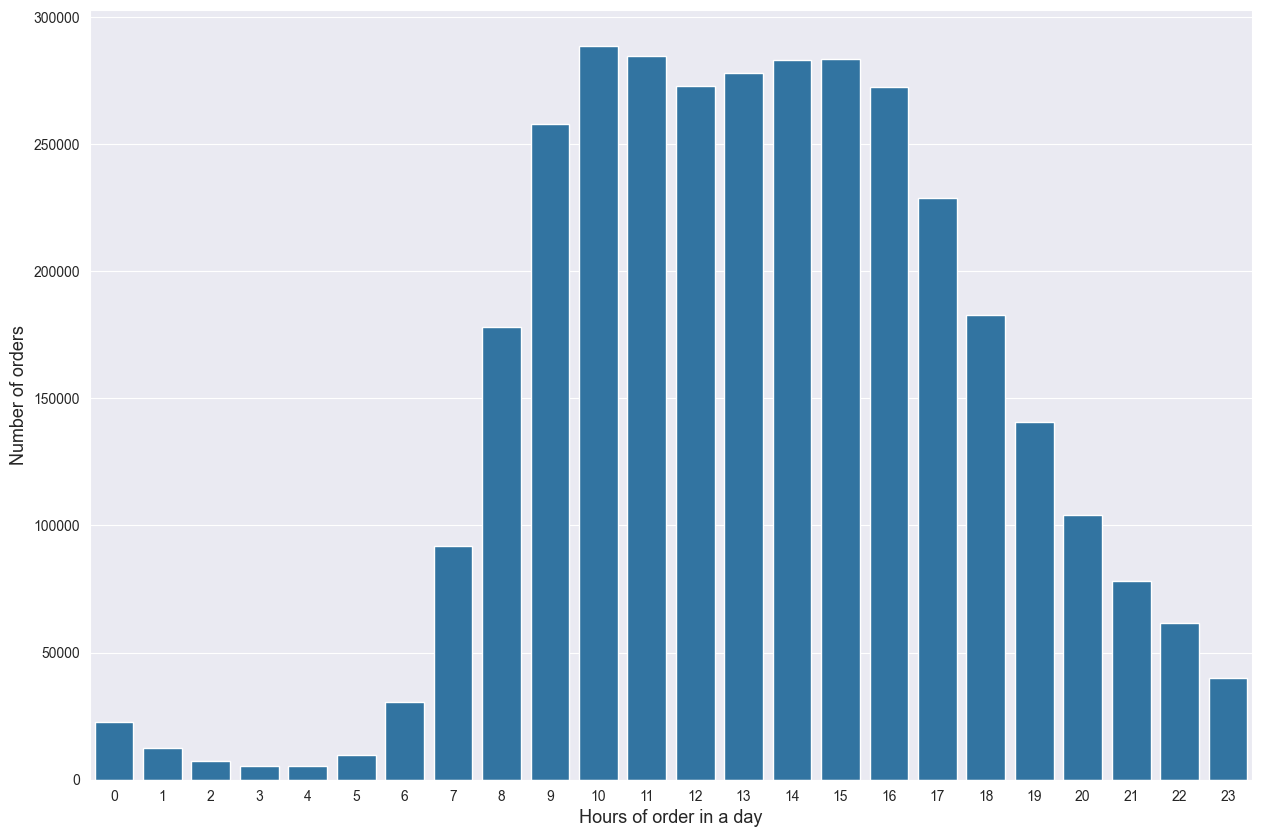

In [18]:
grouped = orders.groupby("order_id")["order_hour_of_day"].aggregate("sum").reset_index()
grouped = grouped.order_hour_of_day.value_counts()

sns.set_style('darkgrid')
f, ax = plt.subplots(figsize=(15, 10))
sns.barplot(x=grouped.index, y=grouped.values)
plt.ylabel('Number of orders', fontsize=13)
plt.xlabel('Hours of order in a day', fontsize=13)
plt.show()

# **Days of Orders in a week:**

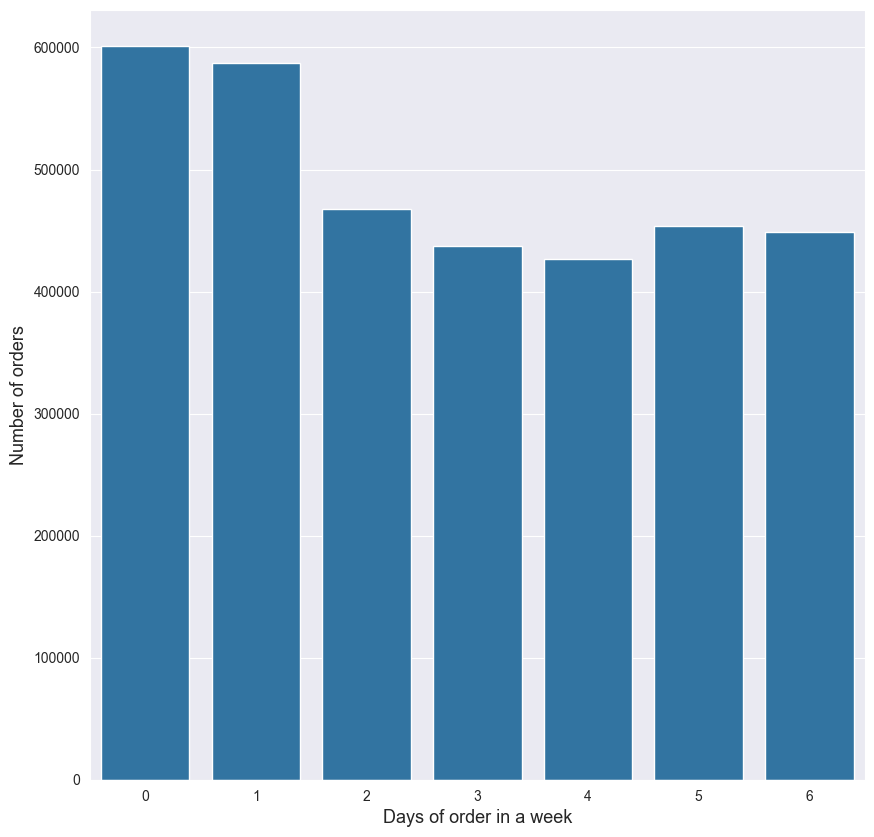

In [19]:
grouped = orders.groupby("order_id")["order_dow"].aggregate("sum").reset_index()
grouped = grouped.order_dow.value_counts()

f, ax = plt.subplots(figsize=(10, 10))
sns.barplot(x=grouped.index, y=grouped.values)
plt.ylabel('Number of orders', fontsize=13)
plt.xlabel('Days of order in a week', fontsize=13)
plt.show()

# **Investigating days since prior order**

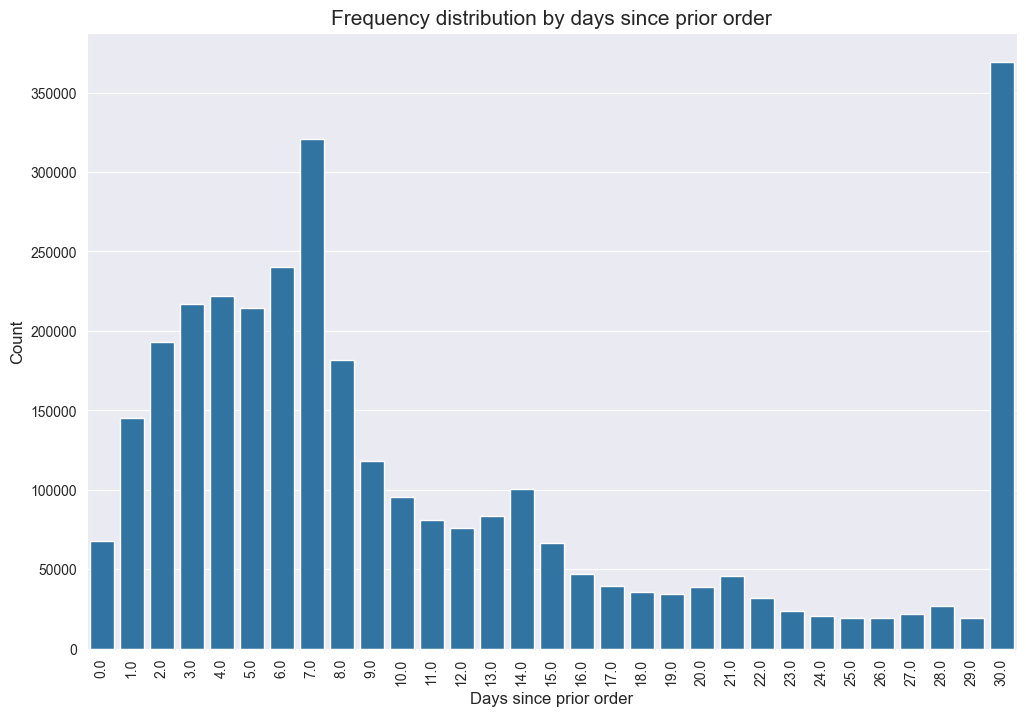

In [20]:
plt.figure(figsize=(12,8))
sns.countplot(x="days_since_prior_order", data=orders)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Days since prior order', fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency distribution by days since prior order", fontsize=15)
plt.show()

# **Orders made by each customer**

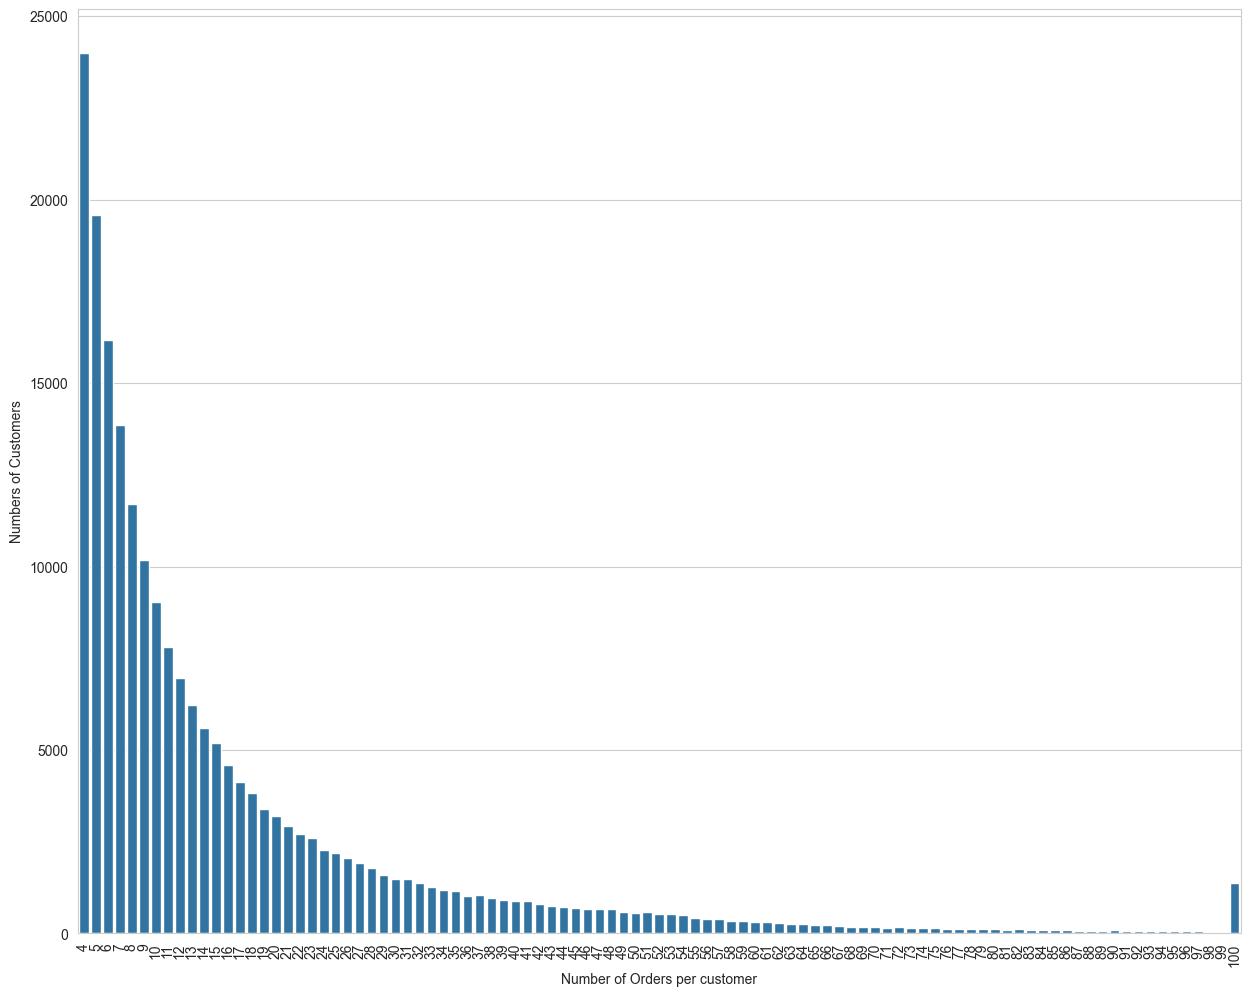

In [21]:
grouped = orders.groupby('user_id')['order_id'].apply(lambda x: len(x.unique())).reset_index()
grouped = grouped.groupby('order_id').aggregate("count")

sns.set_style("whitegrid")
f, ax = plt.subplots(figsize=(15, 12))
sns.barplot(x=grouped.index, y=grouped.user_id)
plt.ylabel('Numbers of Customers')
plt.xlabel('Number of Orders per customer')
plt.xticks(rotation='vertical')
plt.show()

# **Most important Departments (by number of products)**

In [22]:
items  = pd.merge(left = pd.merge(left=products, right=departments, how='left'), right=aisles, how='left')
items.head()

,product_id,product_name,aisle_id,department_id,department,aisle
0,1,Chocolate Sandwich Cookies,61,19,snacks,cookies cakes
1,2,All-Seasons Salt,104,13,pantry,spices seasonings
2,3,Robust Golden Unsweetened Oolong Tea,94,7,beverages,tea
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen,frozen meals
4,5,Green Chile Anytime Sauce,5,13,pantry,marinades meat preparation


In [23]:
grouped = items.groupby("department")["product_id"].aggregate(Total_products=('count')).reset_index()
grouped['Ratio'] = grouped["Total_products"].apply(lambda x: x /grouped['Total_products'].sum())
grouped.sort_values(by='Total_products', ascending=False, inplace=True)
grouped

,department,Total_products,Ratio
17,personal care,6563,0.132084
20,snacks,6264,0.126067
16,pantry,5371,0.108095
3,beverages,4365,0.087848
10,frozen,4007,0.080643
7,dairy eggs,3449,0.069413
11,household,3085,0.062087
6,canned goods,2092,0.042103
9,dry goods pasta,1858,0.037393
19,produce,1684,0.033891


# **Most important Aisles in each Department (by number of Products)**

C:\Users\HUGO\AppData\Local\Temp\ipykernel_20096\723771249.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


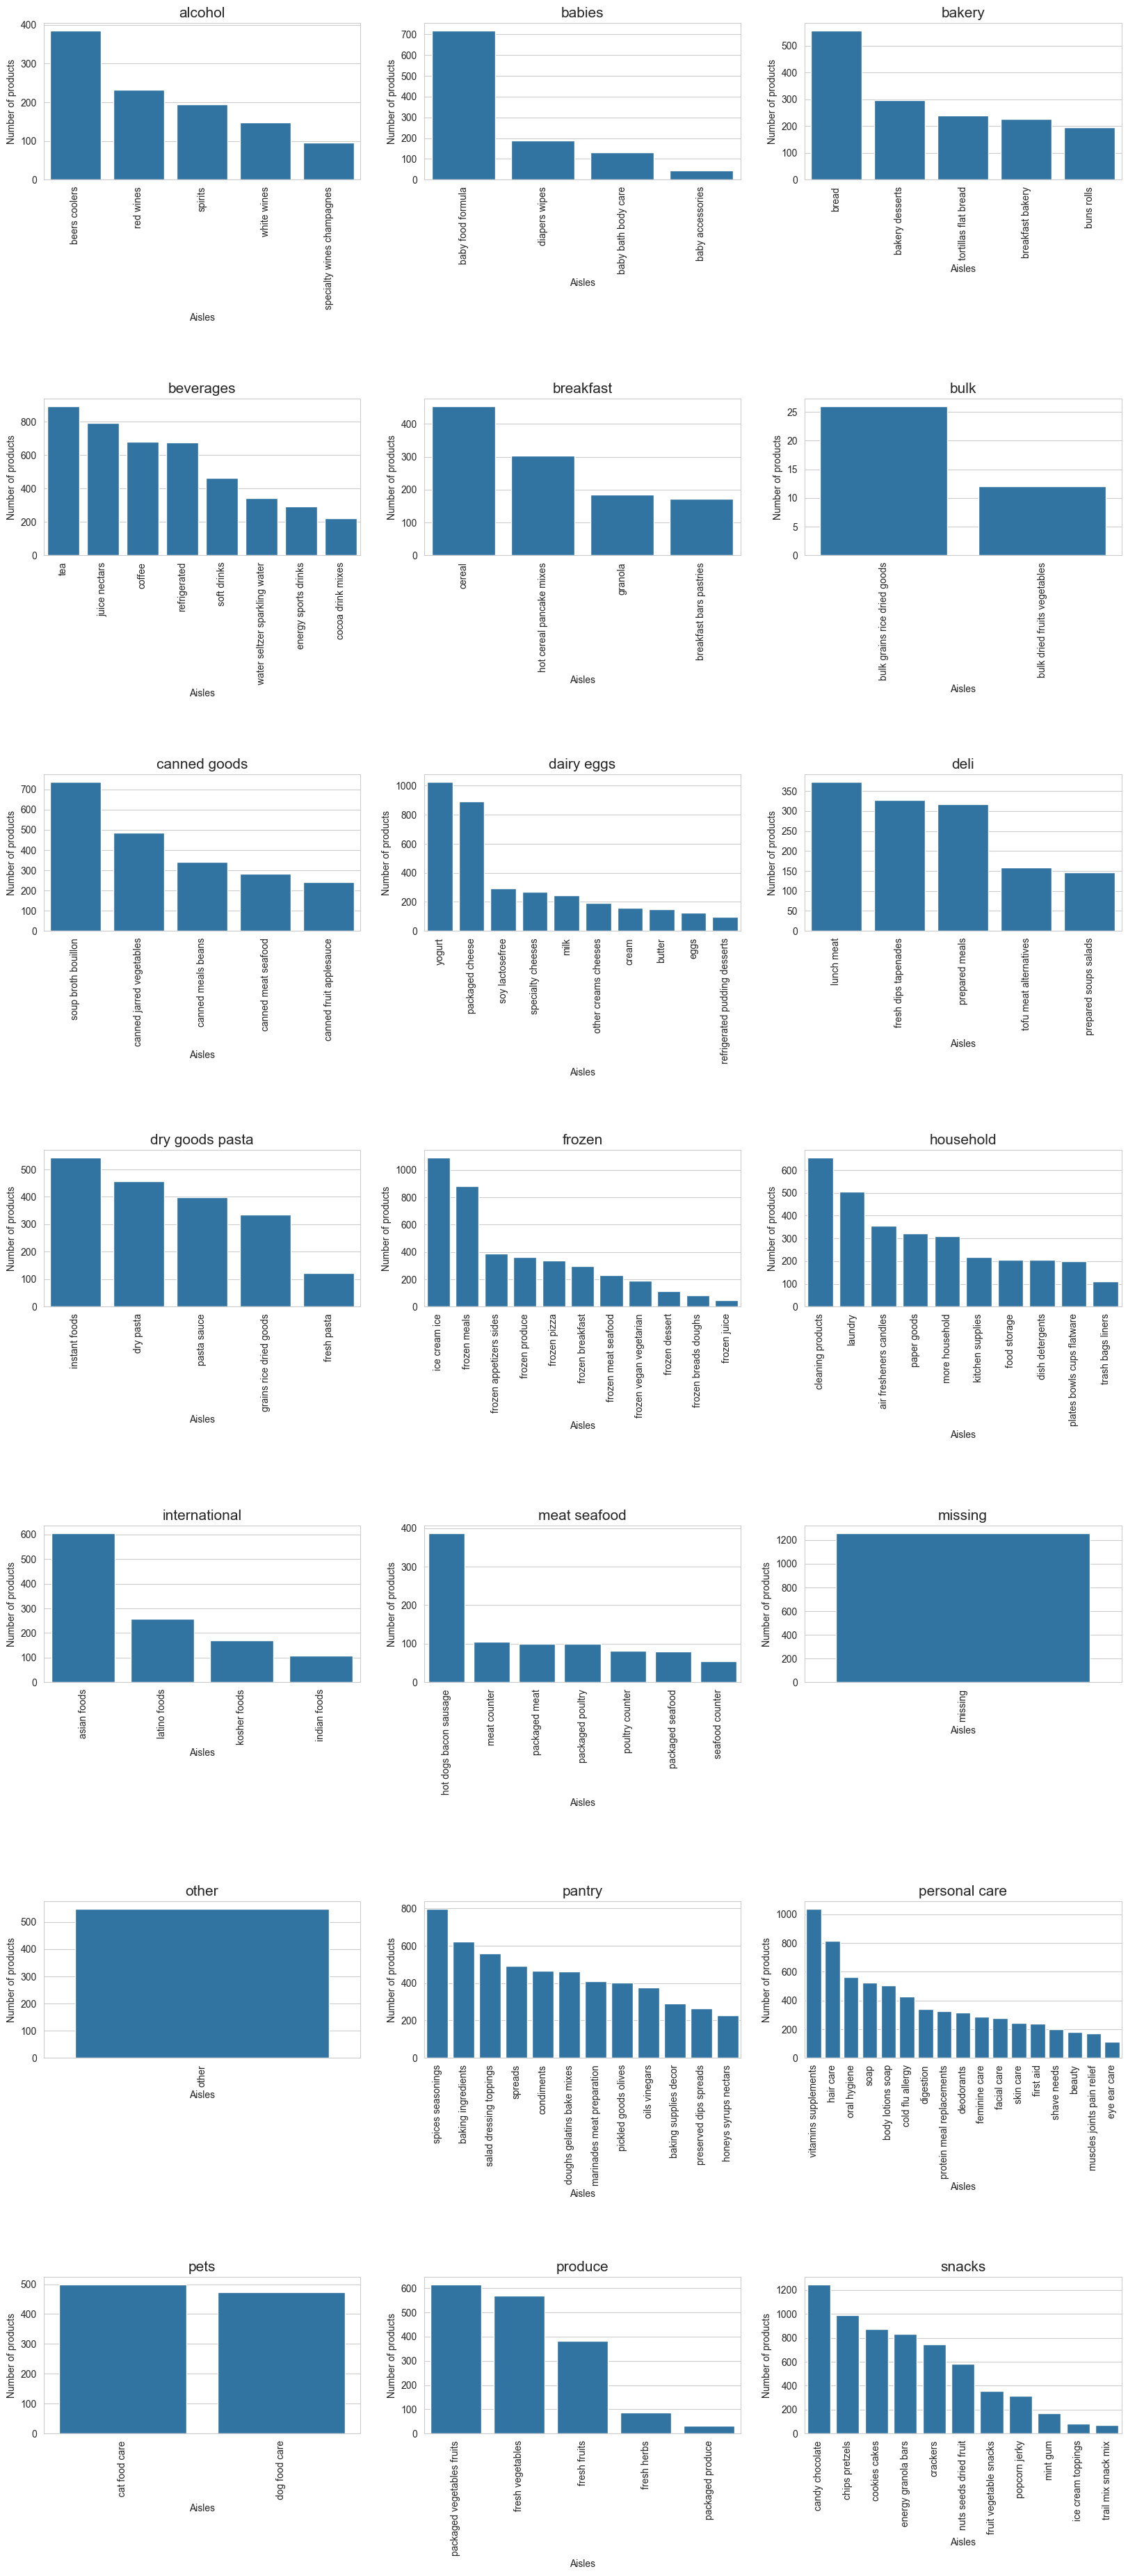

In [24]:
# 1️⃣ Correction du groupby
grouped = (
    items
    .groupby(["department", "aisle"])
    .agg(Total_products=("product_id", "count"))
    .reset_index()
)

grouped.sort_values(by='Total_products', ascending=False, inplace=True)

# 2️⃣ Plot
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(7, 3, figsize=(20, 45), gridspec_kw=dict(hspace=1.4))

for (department, group), ax in zip(grouped.groupby("department"), axes.flatten()):
    
    sns.barplot(
        data=group,
        x="aisle",
        y="Total_products",
        ax=ax
    )
    
    ax.set_xlabel("Aisles")
    ax.set_ylabel("Number of products")
    ax.set_title(department, fontsize=15)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# **products_with_prices**

In [25]:
products_with_prices  = pd.read_csv("C:/Users/HUGO/Downloads/archive/products_with_prices.csv")

# **Merging all the tables togther**

In [26]:
order_products_all = pd.concat(
    [order_products_previous, order_products_train],
    ignore_index=True
)

In [27]:
cust_order = orders[['order_id','user_id']]

In [28]:
order_products_prior_df = pd.merge(order_products_all, products, on='product_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, aisles, on='aisle_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, departments, on='department_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df,cust_order, on='order_id', how='left')
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279


In [29]:
order_products_prior_df.to_csv('order_products_prior_df.csv')

In [30]:
cnt_product_type = order_products_prior_df['product_name'].value_counts().reset_index().head(20)
cnt_product_type.columns = ['product_name', 'frequency_count']
cnt_product_type

,product_name,frequency_count
0,Banana,491291
1,Bag of Organic Bananas,394930
2,Organic Strawberries,275577
3,Organic Baby Spinach,251705
4,Organic Hass Avocado,220877
5,Organic Avocado,184224
6,Large Lemon,160792
7,Strawberries,149445
8,Limes,146660
9,Organic Whole Milk,142813


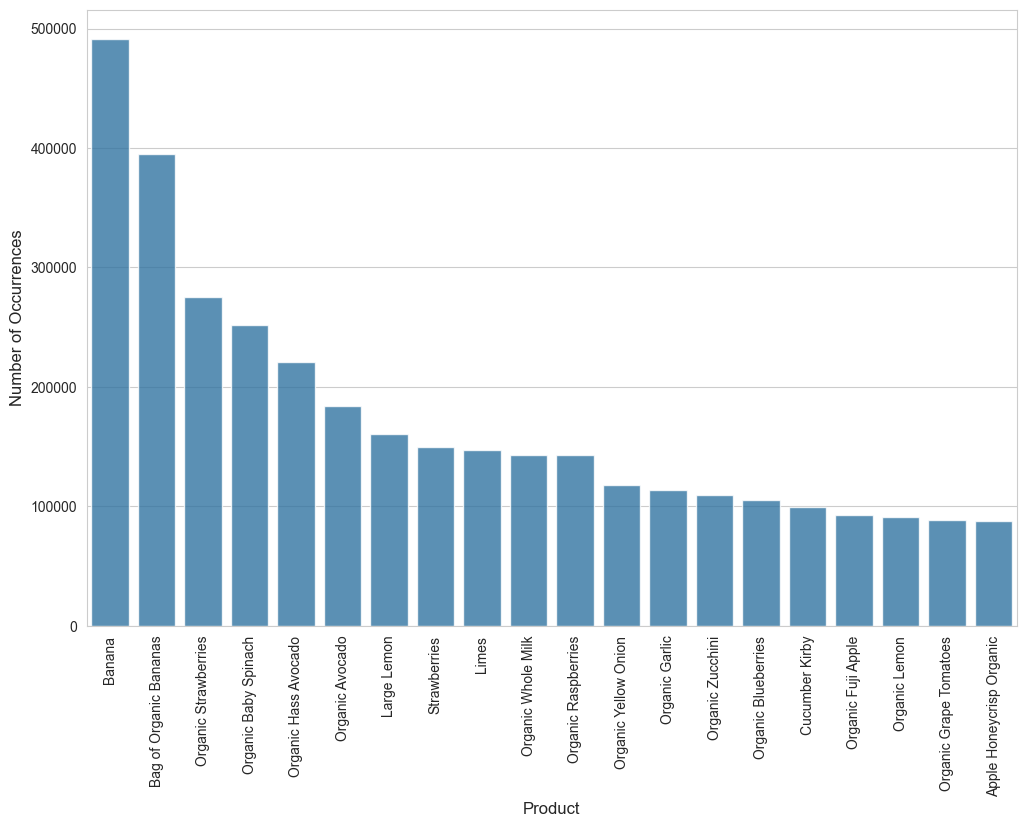

In [31]:
plt.figure(figsize=(12,8))
sns.barplot(data = cnt_product_type , x = cnt_product_type['product_name'], y = cnt_product_type['frequency_count'], alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Product', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

In [32]:
cnt_aisle_type = order_products_prior_df['aisle'].value_counts().reset_index().head(20)
cnt_aisle_type.columns = ['aisle_name', 'frequency_count']
cnt_aisle_type

,aisle_name,frequency_count
0,fresh fruits,3792661
1,fresh vegetables,3568630
2,packaged vegetables fruits,1843806
3,yogurt,1507583
4,packaged cheese,1021462
5,milk,923659
6,water seltzer sparkling water,878150
7,chips pretzels,753739
8,soy lactosefree,664493
9,bread,608469


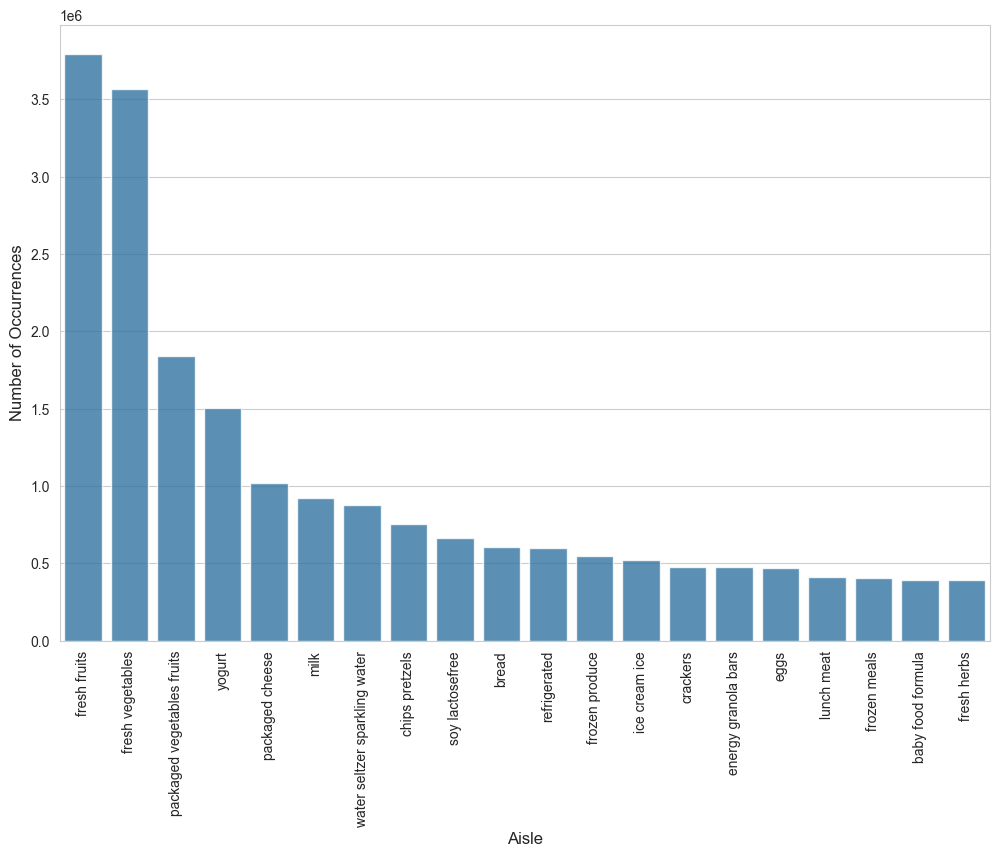

In [33]:
plt.figure(figsize=(12,8))
sns.barplot(data = cnt_aisle_type , x = cnt_aisle_type['aisle_name'], y = cnt_aisle_type['frequency_count'], alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Aisle', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

# **Randomly select 10,000 users**

In [142]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import fpgrowth

In [35]:
sample_users = np.random.choice(
    order_products_prior_df['user_id'].unique(),
    size=10000,
    replace=False
)

sample_df = order_products_prior_df[order_products_prior_df['user_id'].isin(sample_users)]

In [36]:
import numpy as np

# === Simulation de prix (en attendant les data engineers) ===
np.random.seed(42)
products['price'] = np.random.uniform(0.5, 15.0, size=len(products))  # prix réalistes
sample_df = pd.merge(sample_df, products[['product_id', 'price']], on='product_id')

print(f"Prix moyen simulé : {sample_df['price'].mean():.2f} €")

Prix moyen simulé : 7.88 €


In [49]:
# Top 300 produits les plus achetés
top_products = sample_df['product_name'].value_counts().head(300).index

filtered_df = sample_df[sample_df['product_name'].isin(top_products)]

# **Create the basket matrix on the reduced subset**

In [50]:
basket = filtered_df.groupby(['order_id', 'product_name'])['product_id'] \
                    .count() \
                    .unstack() \
                    .fillna(0)

# Convertir en booléen pour FP-Growth
basket = basket.astype(bool)
basket.shape

(135610, 300)

# **Run Apriori**

In [51]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsetss = apriori(basket, min_support=0.01, use_colnames=True)

ruless = association_rules(frequent_itemsets,
                          metric="lift",
                          min_threshold=1)


In [52]:
frequent_itemsetss

,support,itemsets
0,0.015663,(100% Raw Coconut Water)
1,0.010729,(100% Recycled Paper Towels)
2,0.022823,(100% Whole Wheat Bread)
3,0.013281,(2% Reduced Fat Milk)
4,0.031318,(Apple Honeycrisp Organic)
...,...,...
144,0.011717,"(Organic Baby Spinach, Organic Avocado)"
145,0.013023,"(Organic Baby Spinach, Organic Hass Avocado)"
146,0.014660,"(Organic Baby Spinach, Organic Strawberries)"
147,0.015729,"(Organic Hass Avocado, Organic Strawberries)"


In [53]:
ruless

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Organic Baby Carrots),(Bag of Organic Bananas),0.023324,0.116000,0.005026,0.215506,1.857810,1.0,0.002321,1.126841,0.472758,0.037428,0.112563,0.129419
1,(Bag of Organic Bananas),(Organic Baby Carrots),0.116000,0.023324,0.005026,0.043331,1.857810,1.0,0.002321,1.020914,0.522321,0.037428,0.020485,0.129419
2,(Organic Avocado),(Bag of Organic Bananas),0.052630,0.116000,0.007527,0.143024,1.232962,1.0,0.001422,1.031534,0.199442,0.046724,0.030570,0.103957
3,(Bag of Organic Bananas),(Organic Avocado),0.116000,0.052630,0.007527,0.064891,1.232962,1.0,0.001422,1.013112,0.213739,0.046724,0.012942,0.103957
4,(Organic Avocado),(Organic Strawberries),0.052630,0.083917,0.007619,0.144771,1.725170,1.0,0.003203,1.071155,0.443699,0.059098,0.066428,0.117783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,(Apple Honeycrisp Organic),(Organic Hass Avocado),0.026033,0.064988,0.005094,0.195668,3.010829,1.0,0.003402,1.162470,0.685717,0.059281,0.139762,0.137024
160,(Organic Gala Apples),(Banana),0.021516,0.144001,0.005002,0.232479,1.614426,1.0,0.001904,1.115277,0.388953,0.031162,0.103362,0.133607
161,(Banana),(Organic Gala Apples),0.144001,0.021516,0.005002,0.034735,1.614426,1.0,0.001904,1.013695,0.444609,0.031162,0.013510,0.133607
162,(Organic Gala Apples),(Bag of Organic Bananas),0.021516,0.116000,0.005284,0.245584,2.117105,1.0,0.002788,1.171767,0.539259,0.039959,0.146588,0.145567


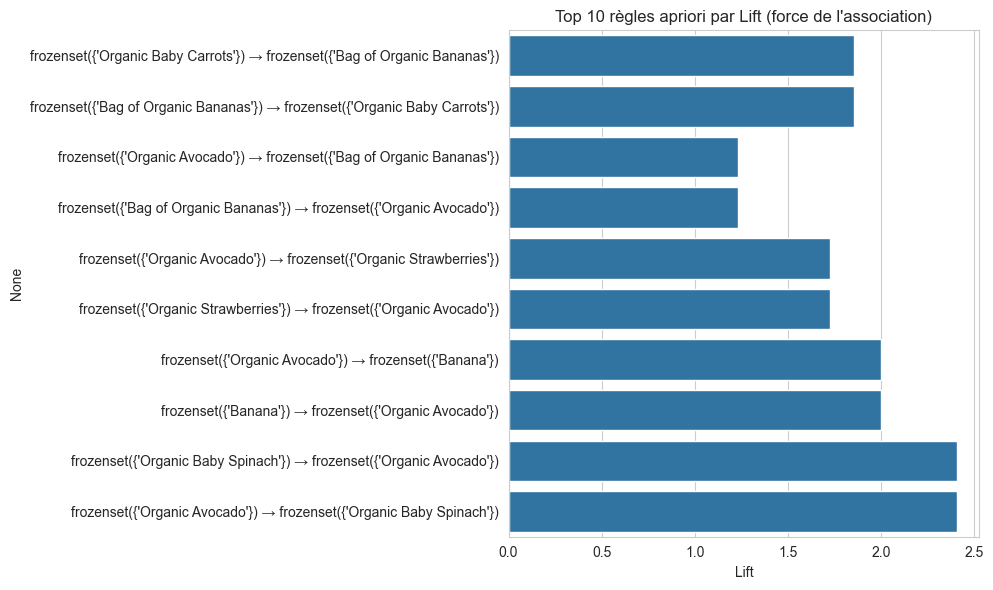

In [57]:
# ====================== 7. VISUALISATION BUSINESS ======================
plt.figure(figsize=(10, 6))
sns.barplot(data=ruless.head(10), 
            y=ruless.head(10)['antecedents'].astype(str) + ' → ' + ruless.head(10)['consequents'].astype(str),
            x='lift')
plt.title('Top 10 règles apriori par Lift (force de l\'association)')
plt.xlabel('Lift')
plt.tight_layout()
plt.show()

In [58]:
sample_df.shape

(1645095, 11)

# **Run FP-Growth**

In [37]:
# === Création du format transactionnel ===
transactions = sample_df.groupby('order_id')['product_name'].apply(list).reset_index()
transactions_list = transactions['product_name'].tolist()

print(f"Nombre de transactions : {len(transactions_list):,}")
print(f"Exemple de panier : {transactions_list[0][:8]}...")

Nombre de transactions : 163,138
Exemple de panier : ['Organic Red Radish, Bunch', 'Whole White Mushrooms', 'Baby Spinach', 'Low Fat Kefir Cultured Milk Smoothie Lowfat Probiotic Blueberry', 'Snak-Saks Crackers', 'Natural Applesauce Snack & Go Pouches', 'Green Beans', 'Extra Virgin Olive Oil']...


In [41]:
import time
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
print("\n=== Exécution FP-Growth ===")
fp_start = time.time()

# Transformation en One-Hot (format requis par mlxtend)
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list, sparse=True)  # sparse = économie mémoire
df_onehot = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

# Paramètres recommandés pour Instacart
min_support_value = 0.005   # = 0.5% des paniers → environ 250 paniers sur 50k

frequent_itemsets = fpgrowth(df_onehot, 
                             min_support=min_support_value, 
                             use_colnames=True,
                             verbose=1)

print(f"Nombre d'itemsets fréquents trouvés : {len(frequent_itemsets):,}")
print(f"Temps FP-Growth : {time.time() - fp_start:.1f} secondes")


=== Exécution FP-Growth ===


C:\Users\HUGO\AppData\Local\Temp\ipykernel_20096\2253268259.py:10: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df_onehot = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)


252 itemset(s) from tree conditioned on items ()
0 itemset(s) from tree conditioned on items (Extra Virgin Olive Oil)
0 itemset(s) from tree conditioned on items (Vanilla Almond Breeze Almond Milk)
0 itemset(s) from tree conditioned on items (Organic Red Radish, Bunch)
0 itemset(s) from tree conditioned on items (Green Beans)
0 itemset(s) from tree conditioned on items (Baby Spinach)
0 itemset(s) from tree conditioned on items (Organic Bread with 21 Whole Grains)
0 itemset(s) from tree conditioned on items (Distilled Water)
1 itemset(s) from tree conditioned on items (Organic Baby Carrots)
0 itemset(s) from tree conditioned on items (Unsweetened Almondmilk)
0 itemset(s) from tree conditioned on items (Bag of Organic Bananas)
4 itemset(s) from tree conditioned on items (Organic Avocado)
0 itemset(s) from tree conditioned on items (Organic Avocado, Bag of Organic Bananas)
0 itemset(s) from tree conditioned on items (Organic Avocado, Organic Strawberries)
0 itemset(s) from tree conditione

In [59]:
# ====================== 5. RÈGLES D'ASSOCIATION ======================
rules = association_rules(frequent_itemsets, 
                          metric="lift", 
                          min_threshold=1.2)

# Ajout de métriques business
rules = rules.sort_values('lift', ascending=False)

# Calcul du revenu estimé par règle (business impact)
def estimate_revenue(row):
    # Prix moyen des antécédents + conséquents
    antecedent_items = list(row['antecedents'])
    consequent_items = list(row['consequents'])
    avg_price_ante = sample_df[sample_df['product_name'].isin(antecedent_items)]['price'].mean()
    avg_price_cons = sample_df[sample_df['product_name'].isin(consequent_items)]['price'].mean()
    return row['support'] * 1645095 * (avg_price_ante + avg_price_cons) * row['confidence']

rules['estimated_revenue_per_100k_orders'] = rules.apply(estimate_revenue, axis=1) * 2  # x2 pour extrapoler

In [60]:
# ====================== 6. RÉSULTATS PRÉCIS (à copier dans ton rapport) ======================
print("\n=== TOP 15 RÈGLES LES PLUS INTÉRESSANTES (triées par Lift) ===")
top_rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 
                   'estimated_revenue_per_100k_orders']].head(15).round(4)

display(top_rules)   # Dans Jupyter ça affiche un beau tableau


=== TOP 15 RÈGLES LES PLUS INTÉRESSANTES (triées par Lift) ===


,antecedents,consequents,support,confidence,lift,estimated_revenue_per_100k_orders
79,(Organic Garlic),(Organic Yellow Onion),0.0070,0.2119,5.9341,111594.6553
78,(Organic Yellow Onion),(Organic Garlic),0.0070,0.1965,5.9341,103492.2627
23,(Limes),(Organic Cilantro),0.0052,0.1272,5.6804,21126.8980
22,(Organic Cilantro),(Limes),0.0052,0.2321,5.6804,38536.0633
42,(Large Lemon),(Limes),0.0078,0.1737,4.2525,52196.8799
43,(Limes),(Large Lemon),0.0078,0.1899,4.2525,57068.0666
113,(Organic Hass Avocado),"(Bag of Organic Bananas, Organic Strawberries)",0.0052,0.0796,3.9850,31639.2328
112,"(Bag of Organic Bananas, Organic Strawberries)",(Organic Hass Avocado),0.0052,0.2590,3.9850,102927.0164
26,(Organic Hass Avocado),(Organic Cucumber),0.0062,0.0958,3.5596,41100.8135
27,(Organic Cucumber),(Organic Hass Avocado),0.0062,0.2313,3.5596,99214.6685


In [ ]:
# Export pour ton équipe / dashboard
top_rules.to_csv('fp_growth_top_rules.csv', index=False)
frequent_itemsets.to_csv('fp_growth_frequent_itemsets.csv', index=False)

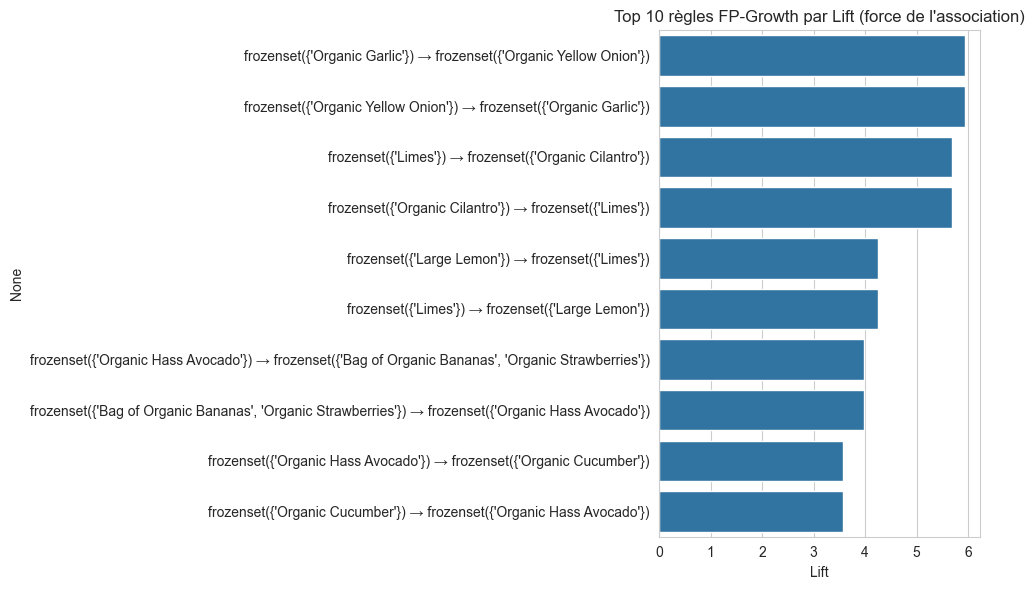

In [45]:
# ====================== 7. VISUALISATION BUSINESS ======================
plt.figure(figsize=(10, 6))
sns.barplot(data=top_rules.head(10), 
            y=top_rules.head(10)['antecedents'].astype(str) + ' → ' + top_rules.head(10)['consequents'].astype(str),
            x='lift')
plt.title('Top 10 règles FP-Growth par Lift (force de l\'association)')
plt.xlabel('Lift')
plt.tight_layout()
plt.show()